In [50]:
import os
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.api import layers, Model, optimizers
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示

In [51]:
def detrend_segment(segment, order=1):
    """
    segment: shape (200,)
    返回去除趋势后的信号
    """
    x = np.arange(len(segment))
    coeffs = np.polyfit(x, segment, order)
    trend = np.polyval(coeffs, x)
    return segment - trend

In [52]:
import sqlite3

def load_data(folder_path: str) -> dict:
    # 初始化datalist字典，包含所有传感器数据的列表
    datalist = {
        'CO2_concentration': [],
        'TVOC_concentration': [],
        'temperature': [],
        'humidity': [],
        'pressure': []
    }
    
    # 获取文件夹中所有的.db文件
    db_files = [f for f in os.listdir(folder_path) if f.endswith('.db')]
    for db_file in db_files:
        db_path = os.path.join(folder_path, db_file)
        with sqlite3.connect(db_path) as database:
            database_cursor = database.cursor()
            query_sql = "SELECT * FROM sensor_data"  
            database_cursor.execute(query_sql)
            results = database_cursor.fetchall()

        # 将数据存储到列表中
        CO2_concentration = np.array([row[2] for row in results])
        TVOC_concentration = np.array([row[3] for row in results])
        temperature = np.array([row[4] for row in results])
        humidity = np.array([row[5] for row in results])
        pressure = np.array([row[6] for row in results])

        # 将数据划分为以200个数据点（5s）一组
        CO2_concentration = np.array([CO2_concentration[i:i+200] for i in range(len(CO2_concentration) // 200)])
        TVOC_concentration = np.array([TVOC_concentration[i:i+200] for i in range(len(TVOC_concentration) // 200)])
        temperature = np.array([temperature[i:i+200] for i in range(len(temperature) // 200)])
        humidity = np.array([humidity[i:i+200] for i in range(len(humidity) // 200)])
        pressure = np.array([pressure[i:i+200] for i in range(len(pressure) // 200)])

        # 应用detrend函数
        CO2_concentration = np.array([detrend_segment(data) for data in CO2_concentration])
        TVOC_concentration = np.array([detrend_segment(data) for data in TVOC_concentration])
        temperature = np.array([detrend_segment(data) for data in temperature])
        humidity = np.array([detrend_segment(data) for data in humidity])
        pressure = np.array([detrend_segment(data) for data in pressure])

        # 重塑数据形状
        CO2_concentration = CO2_concentration.reshape(len(CO2_concentration), 200, 1)
        TVOC_concentration = TVOC_concentration.reshape(len(TVOC_concentration), 200, 1)
        temperature = temperature.reshape(len(temperature), 200, 1)
        humidity = humidity.reshape(len(humidity), 200, 1)
        pressure = pressure.reshape(len(pressure), 200, 1)

        # 将当前数据库的数据追加到datalist中
        datalist['CO2_concentration'].append(CO2_concentration)
        datalist['TVOC_concentration'].append(TVOC_concentration)
        datalist['temperature'].append(temperature)
        datalist['humidity'].append(humidity)
        datalist['pressure'].append(pressure)

    # 将所有数据库的数据合并为一个数组
    final_data = {
        'CO2_concentration': np.concatenate(datalist['CO2_concentration'], axis=0),
        'TVOC_concentration': np.concatenate(datalist['TVOC_concentration'], axis=0),
        'temperature': np.concatenate(datalist['temperature'], axis=0),
        'humidity': np.concatenate(datalist['humidity'], axis=0),
        'pressure': np.concatenate(datalist['pressure'], axis=0)
    }
    
    return final_data


In [53]:
# 创建单个传感器分支
def create_branch(name):
    # 输入层
    input = layers.Input(shape=(200, 1), name= f"{name}_input")

    # 卷积层
    x = layers.Conv1D(8, 20, activation='relu', name= f"{name}_conv1")(input)
    x = layers.MaxPooling1D(2, name= f"{name}_maxpool1")(x)

    # x = layers.Conv1D(16, 10, activation='relu', name= f"{name}_conv2")(x)
    # x = layers.MaxPooling1D(2, name= f"{name}_maxpool2")(x)

    # 扁平化
    x = layers.Flatten(name= f"{name}_flatten")(x)

    # 全连接层
    x = layers.Dense(32, activation='relu')(x)

    return Model(inputs=input, outputs=x, name=name)

In [54]:
def create_model():
    # 创建各个传感器的输入层
    # CO2_input = layers.Input(shape=(200, 1), name='CO2_concentration_input')
    # TVOC_input = layers.Input(shape=(200, 1), name='TVOC_concentration_input')
    temperature_input = layers.Input(shape=(200, 1), name='temperature_input')
    humidity_input = layers.Input(shape=(200, 1), name='humidity_input')
    pressure_input = layers.Input(shape=(200, 1), name='pressure_input')

    # 创建各个传感器的分支
    # CO2_branch = create_branch('CO2_concentration')(CO2_input)
    # TVOC_branch = create_branch('TVOC_concentration')(TVOC_input)
    temperature_branch = create_branch('temperature')(temperature_input)
    humidity_branch = create_branch('humidity')(humidity_input)
    pressure_branch = create_branch('pressure')(pressure_input)

    # 合并分支
    # merged = layers.concatenate([CO2_branch, TVOC_branch, temperature_branch, humidity_branch, pressure_branch], name='merged')
    merged = layers.concatenate([temperature_branch, humidity_branch, pressure_branch], name='merged')


    # # 全连接层
    # x = layers.Dense(64, activation='relu')(merged)
    # x = layers.Dropout(0.5, name='dropout')(x)

    # 输出层
    output = layers.Dense(2, activation='sigmoid', name='output')(merged) # 输出层有2个神经元，对应2个类别

    # return Model(inputs=[CO2_input, TVOC_input, temperature_input, humidity_input, pressure_input], outputs=output, name='sensor_model')
    return Model(inputs=[temperature_input, humidity_input, pressure_input], outputs=output, name='sensor_model')

In [55]:
# K折交叉验证
def k_fold_cross_validation(X_dict, y, n_splits=5, n_repeats=1, epochs=40, batch_size=128):
    """
    K折交叉验证函数
    """
    
    # 创建重复K折交叉验证器
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    
    # 存储每折的结果
    fold_results = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'histories': []
    }
    
    fold = 1
    total_folds = n_splits * n_repeats
    
    # 准备输入数据
    X_inputs = [X_dict['temperature'], X_dict['humidity'], X_dict['pressure']]
    
    for train_index, val_index in rkf.split(X_inputs[0]):
        print(f"\n{'='*50}")
        print(f"训练第 {fold}/{total_folds} 折")
        print(f"{'='*50}")
        
        # 划分训练集和验证集
        X_train = [x[train_index] for x in X_inputs]
        X_val = [x[val_index] for x in X_inputs]
        y_train = y[train_index]
        y_val = y[val_index]
        
        # 创建新模型（重要：每折都要重新创建）
        model = create_model()
        model.compile(
            optimizer=optimizers.RMSprop(learning_rate=0.0002),
            loss='categorical_crossentropy', 
            metrics=['accuracy']
        )
        
        # 训练模型
        history = model.fit(
            X_train, 
            y_train, 
            epochs=epochs, 
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            verbose=1
        )
        
        # 存储结果
        fold_results['train_loss'].append(history.history['loss'][-1])
        fold_results['val_loss'].append(history.history['val_loss'][-1])
        fold_results['train_accuracy'].append(history.history['accuracy'][-1])
        fold_results['val_accuracy'].append(history.history['val_accuracy'][-1])
        fold_results['histories'].append(history)
        
        fold += 1
    
    return fold_results


In [56]:
def plot_cross_validation_results(results, n_splits=5, n_repeats=1):
    """
    绘制交叉验证结果
    """
    total_folds = n_splits * n_repeats
    
    # 创建子图
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    # 1. 每折的准确率
    folds = range(1, total_folds + 1)
    ax1.bar(folds, results['train_accuracy'], alpha=0.7, label='训练准确率', color='blue')
    ax1.bar(folds, results['val_accuracy'], alpha=0.7, label='验证准确率', color='red')
    ax1.set_xlabel('折数')
    ax1.set_ylabel('准确率')
    ax1.set_title('每折的训练和验证准确率')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. 每折的损失
    ax2.bar(folds, results['train_loss'], alpha=0.7, label='训练损失', color='blue')
    ax2.bar(folds, results['val_loss'], alpha=0.7, label='验证损失', color='red')
    ax2.set_xlabel('折数')
    ax2.set_ylabel('损失')
    ax2.set_title('每折的训练和验证损失')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 准确率统计 - 修复这里的问题
    categories = ['训练准确率', '验证准确率']
    min_values = [np.min(results['train_accuracy']), np.min(results['val_accuracy'])]
    mean_values = [np.mean(results['train_accuracy']), np.mean(results['val_accuracy'])]
    max_values = [np.max(results['train_accuracy']), np.max(results['val_accuracy'])]
    
    x = np.arange(len(categories))
    width = 0.25
    
    ax3.bar(x - width, min_values, width, label='最小值', alpha=0.7, color='red')
    ax3.bar(x, mean_values, width, label='平均值', alpha=0.7, color='green')
    ax3.bar(x + width, max_values, width, label='最大值', alpha=0.7, color='blue')
    
    ax3.set_ylabel('准确率')
    ax3.set_title('准确率统计')
    ax3.set_xticks(x)
    ax3.set_xticklabels(categories)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. 训练曲线示例（显示第一折的训练过程）
    if results['histories']:
        history = results['histories'][0]
        epochs_range = range(1, len(history.history['loss']) + 1)
        ax4.plot(epochs_range, history.history['loss'], 'b-', label='训练损失')
        ax4.plot(epochs_range, history.history['val_loss'], 'r-', label='验证损失')
        ax4.set_xlabel('轮次')
        ax4.set_ylabel('损失')
        ax4.set_title('第一折训练过程 - 损失')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # 创建第二个y轴用于准确率
        ax4_twin = ax4.twinx()
        ax4_twin.plot(epochs_range, history.history['accuracy'], 'b--', label='训练准确率')
        ax4_twin.plot(epochs_range, history.history['val_accuracy'], 'r--', label='验证准确率')
        ax4_twin.set_ylabel('准确率')
        ax4_twin.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print("\n" + "="*60)
    print("交叉验证结果统计")
    print("="*60)
    print(f"训练准确率: {np.mean(results['train_accuracy']):.4f} ± {np.std(results['train_accuracy']):.4f}")
    print(f"验证准确率: {np.mean(results['val_accuracy']):.4f} ± {np.std(results['val_accuracy']):.4f}")
    print(f"训练损失: {np.mean(results['train_loss']):.4f} ± {np.std(results['train_loss']):.4f}")
    print(f"验证损失: {np.mean(results['val_loss']):.4f} ± {np.std(results['val_loss']):.4f}")
    print(f"最佳验证准确率: {np.max(results['val_accuracy']):.4f}")
    print(f"最差验证准确率: {np.min(results['val_accuracy']):.4f}")


开始训练...

训练第 1/36 折
Epoch 1/20


/home/guo/anaconda3/envs/TensorFlow/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['temperature_input', 'humidity_input', 'pressure_input']. Received: the structure of inputs=('*', '*', '*')
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.5588 - loss: 2.5667 - val_accuracy: 0.6693 - val_loss: 0.5823
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7155 - loss: 0.4985 - val_accuracy: 0.7211 - val_loss: 0.3858
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7555 - loss: 0.3473 - val_accuracy: 0.7809 - val_loss: 0.3090
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8085 - loss: 0.5447 - val_accuracy: 0.8486 - val_loss: 0.2471
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8674 - loss: 0.2848 - val_accuracy: 0.9124 - val_loss: 0.2009
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9231 - loss: 0.2718 - val_accuracy: 0.9363 - val_loss: 0.1760
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9538 - loss: 0.2640 - val_accuracy: 0.9801 - val_loss: 0.1433
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9660 - loss: 0.2028 - val_accuracy: 0.9841 - val_loss: 0.1248
E

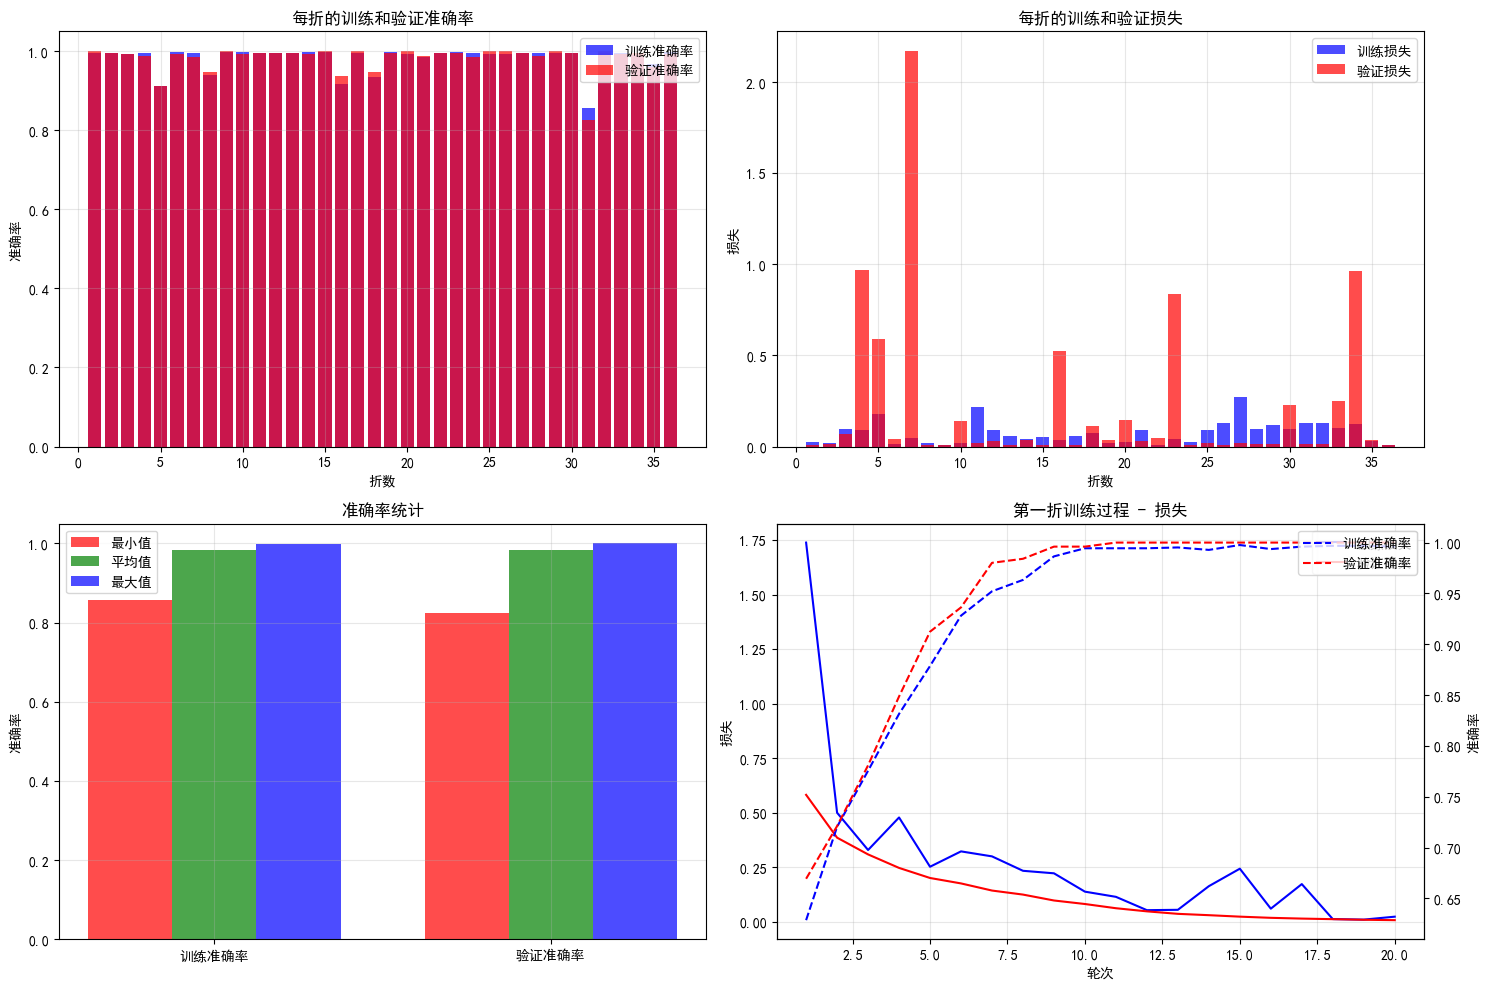


交叉验证结果统计
训练准确率: 0.9827 ± 0.0311
验证准确率: 0.9826 ± 0.0334
训练损失: 0.0742 ± 0.0601
验证损失: 0.2073 ± 0.4261
最佳验证准确率: 1.0000
最差验证准确率: 0.8247


In [57]:
if __name__ == '__main__':
    # 指定文件夹路径
    health_folder = './health_data_folder'
    ill_folder = './ill_data_folder'
    
    # 设置交叉验证参数
    splits = 6
    repeats = 6

    # 加载数据
    Sensor_data_health = load_data(health_folder)
    Sensor_data_ill = load_data(ill_folder)

    # 标签
    # 0 = ill
    # 1 = health
    initial_tag = np.concatenate((np.zeros(len(Sensor_data_ill['CO2_concentration'])), np.ones(len(Sensor_data_health['CO2_concentration']))))

    # 将标签转换为one-hot编码
    from keras.api.utils import to_categorical
    initial_tag = to_categorical(initial_tag)

    # 合并传感器数据
    # np.concatenate 用于将两个数组沿指定轴连接起来
    initial_sensor_data = {
        'CO2_concentration': np.concatenate((Sensor_data_ill['CO2_concentration'], Sensor_data_health['CO2_concentration'])),
        'TVOC_concentration': np.concatenate((Sensor_data_ill['TVOC_concentration'], Sensor_data_health['TVOC_concentration'])),
        'temperature': np.concatenate((Sensor_data_ill['temperature'], Sensor_data_health['temperature'])),
        'humidity': np.concatenate((Sensor_data_ill['humidity'], Sensor_data_health['humidity'])),
        'pressure': np.concatenate((Sensor_data_ill['pressure'], Sensor_data_health['pressure']))
    }

    data_length = len(initial_sensor_data['CO2_concentration'])

    # 打乱数据顺序（生成随机索引）
    indices = np.random.permutation(data_length)

    # 将数据按照随机索引重新排列
    Sensor_data = {}
    for key, data in initial_sensor_data.items():
        Sensor_data[key] = data[indices]

    # 将标签按照随机索引重新排列
    tag = initial_tag[indices]

    print("开始训练...")
    results = k_fold_cross_validation(
        X_dict=Sensor_data, 
        y=tag, 
        n_splits=splits, 
        n_repeats=repeats,
        epochs=20, 
        batch_size=128
    )

    # 绘制结果
    plot_cross_validation_results(results, n_splits=splits, n_repeats=repeats)